In [218]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [219]:
'''
data_dir = Path("../data/raw")
txt_files = list(data_dir.glob("*.txt"))
output_path = Path("../data/processed/")
output_path.mkdir(parents=True, exist_ok=True)

# 제출/재실행 시 바로 원인을 알 수 있도록 입력 파일 존재 여부를 먼저 확인
if not txt_files:
    raise FileNotFoundError(f"입력 파일을 찾을 수 없습니다: {data_dir.resolve()}")

# 파일 이름에서 subject_id, sensor, device 추출
def parse_filename(file_path):
    name = file_path.stem  # 예: data_1600_accel_watch

    parts = name.split("_")

    subject_id = parts[1]      # 1600
    sensor = parts[2]          # accel or gyro
    device = parts[3]          # watch

    return subject_id, sensor, device

# 각 txt 파일을 읽어서 센서 데이터프레임으로 변환
def load_sensor_file(file_path):
    subject_id_from_name, sensor, device = parse_filename(file_path)

    raw_df = pd.read_csv(
        file_path,
        sep=",",
        header=None,
        engine="python"
    )

    raw_df.columns = ["subject_id", "activity", "timestamp", "x", "y", "z"]

    # 원본 데이터의 z축 끝 세미콜론 제거
    raw_df["z"] = raw_df["z"].astype(str).str.replace(";", "", regex=False)

    # 모델 학습 전 숫자형/문자형 타입 정리
    raw_df["subject_id"] = raw_df["subject_id"].astype(str)
    raw_df["activity"] = raw_df["activity"].astype(str)
    raw_df["timestamp"] = pd.to_numeric(raw_df["timestamp"], errors="coerce")
    raw_df["x"] = pd.to_numeric(raw_df["x"], errors="coerce")
    raw_df["y"] = pd.to_numeric(raw_df["y"], errors="coerce")
    raw_df["z"] = pd.to_numeric(raw_df["z"], errors="coerce")

    # 파일명에서 분리한 메타정보 추가
    raw_df["sensor"] = sensor
    raw_df["device"] = device

    return raw_df

# 모든 파일을 읽어서 하나의 데이터프레임으로 결합
all_dfs = []
for file_path in txt_files:
    df = load_sensor_file(file_path)
    all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)

# 본 과제에서는 A, D, E 활동만 사용
selected_activities = ["A", "D", "E"]
filtered_df = full_df[full_df["activity"].isin(selected_activities)].copy()

# 활동 코드에 대한 이름 매핑
activity_map = {
    "A": "Walking",
    "D": "Sitting",
    "E": "Standing"
}
filtered_df["activity_name"] = filtered_df["activity"].map(activity_map)

# 필요한 열만 선택하여 최종 데이터프레임 생성
filtered_df = filtered_df[
    ["subject_id", "activity", "activity_name", "timestamp", "sensor", "device", "x", "y", "z"]
]

# 전처리 중간 결과 저장
filtered_df.to_csv(output_path / "sensor_ADE.csv", index=False)
'''

'\ndata_dir = Path("../data/raw")\ntxt_files = list(data_dir.glob("*.txt"))\noutput_path = Path("../data/processed/")\noutput_path.mkdir(parents=True, exist_ok=True)\n\n# 제출/재실행 시 바로 원인을 알 수 있도록 입력 파일 존재 여부를 먼저 확인\nif not txt_files:\n    raise FileNotFoundError(f"입력 파일을 찾을 수 없습니다: {data_dir.resolve()}")\n\n# 파일 이름에서 subject_id, sensor, device 추출\ndef parse_filename(file_path):\n    name = file_path.stem  # 예: data_1600_accel_watch\n\n    parts = name.split("_")\n\n    subject_id = parts[1]      # 1600\n    sensor = parts[2]          # accel or gyro\n    device = parts[3]          # watch\n\n    return subject_id, sensor, device\n\n# 각 txt 파일을 읽어서 센서 데이터프레임으로 변환\ndef load_sensor_file(file_path):\n    subject_id_from_name, sensor, device = parse_filename(file_path)\n\n    raw_df = pd.read_csv(\n        file_path,\n        sep=",",\n        header=None,\n        engine="python"\n    )\n\n    raw_df.columns = ["subject_id", "activity", "timestamp", "x", "y", "z"]\n\n    # 원본 데이터의 z축 끝 세미콜론

In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. 설정
# ============================================================
DATA_PATH = "../data/processed/sensor_ADE.csv"

WINDOW_SIZE = 50
STEP_SIZE = 25
SKIP_HEAD = 80
NOISE_STD_MULTIPLIER = 1.5

FEATURE_COLUMNS = ["x", "y", "z", "magnitude"]

TARGET_ACTIVITIES = ["Standing", "Sitting", "Walking"]

ACTIVITY_MAP = {
    "A": "Walking",
    "D": "Sitting",
    "E": "Standing",
}

# ============================================================
# 1. 데이터 로드 및 정제
#    - 기존 기능 유지용 필터는 그대로 둠
# ============================================================
df = pd.read_csv(DATA_PATH)

# activity_name 컬럼이 없고 act만 있으면 activity_name 생성
if "activity_name" not in df.columns and "act" in df.columns:
    df["activity_name"] = df["act"].map(ACTIVITY_MAP)

# 기존 의도 유지:
# 1600~1650, watch, Standing/Sitting/Walking 만 사용
df = df[
    (df["subject_id"].between(1600, 1650)) &
    (df["device"] == "watch") &
    (df["activity_name"].isin(TARGET_ACTIVITIES))
].copy()

df = df.sort_values(["subject_id", "activity_name", "sensor", "timestamp"]).copy()

df["magnitude"] = np.sqrt(
    df["x"]**2 + df["y"]**2 + df["z"]**2
)

print("filtered df shape:", df.shape)

# ============================================================
# 2. 기존 feature 추출 함수 유지
# ============================================================
def extract_window_features(window_df, prefix):
    features = {}

    for col in FEATURE_COLUMNS:
        values = window_df[col].to_numpy()

        features[f"{prefix}_{col}_mean"] = values.mean()
        features[f"{prefix}_{col}_std"] = values.std()
        features[f"{prefix}_{col}_min"] = values.min()
        features[f"{prefix}_{col}_max"] = values.max()
        features[f"{prefix}_{col}_range"] = values.max() - values.min()
        features[f"{prefix}_{col}_median"] = np.median(values)
        features[f"{prefix}_{col}_energy"] = np.mean(values ** 2)

    return features


def build_sensor_feature_df(
    source_df,
    sensor_name,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    skip_head=SKIP_HEAD,
    apply_noise_filter=True,
    noise_std_multiplier=1.5
):
    rows = []

    sensor_df = source_df[source_df["sensor"] == sensor_name].copy()

    for (subject_id, activity_name), group in sensor_df.groupby(["subject_id", "activity_name"]):
        group = group.sort_values("timestamp").reset_index(drop=True)

        if skip_head > 0:
            group = group.iloc[skip_head:].reset_index(drop=True)

        n = len(group)
        group_rows = []
        window_seq = 0

        for start in range(0, n - window_size + 1, step_size):
            window_df = group.iloc[start:start + window_size].copy()

            magnitude = np.sqrt(
                window_df["x"].to_numpy() ** 2 +
                window_df["y"].to_numpy() ** 2 +
                window_df["z"].to_numpy() ** 2
            )
            noise_score = float(np.std(magnitude, ddof=0))

            feat = extract_window_features(window_df, prefix=sensor_name)
            feat["subject_id"] = subject_id
            feat["activity_name"] = activity_name
            feat["window_seq"] = window_seq
            feat["noise_score"] = noise_score

            group_rows.append(feat)
            window_seq += 1

        if len(group_rows) == 0:
            continue

        group_feat_df = pd.DataFrame(group_rows)

        if apply_noise_filter:
            score_mean = group_feat_df["noise_score"].mean()
            score_std = group_feat_df["noise_score"].std(ddof=0)
            threshold = score_mean + noise_std_multiplier * score_std

            group_feat_df = group_feat_df[group_feat_df["noise_score"] <= threshold].copy()

        rows.append(group_feat_df)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)

# ============================================================
# 3. 시각화용 noise meta 생성 함수 추가
#    - 기존 feature 생성 로직은 건드리지 않음
#    - boxplot용 전체 윈도우 noise_score 분포 확인용
# ============================================================
def build_window_noise_meta_df(
    source_df,
    sensor_name,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    skip_head=SKIP_HEAD,
    noise_std_multiplier=1.5
):
    rows = []

    sensor_df = source_df[source_df["sensor"] == sensor_name].copy()

    for (subject_id, activity_name), group in sensor_df.groupby(["subject_id", "activity_name"]):
        group = group.sort_values("timestamp").reset_index(drop=True)

        if skip_head > 0:
            group = group.iloc[skip_head:].reset_index(drop=True)

        n = len(group)
        group_rows = []
        window_seq = 0

        for start in range(0, n - window_size + 1, step_size):
            window_df = group.iloc[start:start + window_size].copy()

            magnitude = np.sqrt(
                window_df["x"].to_numpy() ** 2 +
                window_df["y"].to_numpy() ** 2 +
                window_df["z"].to_numpy() ** 2
            )
            noise_score = float(np.std(magnitude, ddof=0))

            group_rows.append({
                "subject_id": subject_id,
                "activity_name": activity_name,
                "sensor": sensor_name,
                "window_seq": window_seq,
                "start_idx": start,
                "noise_score": noise_score
            })
            window_seq += 1

        if len(group_rows) == 0:
            continue

        group_df = pd.DataFrame(group_rows)

        score_mean = group_df["noise_score"].mean()
        score_std = group_df["noise_score"].std(ddof=0)
        threshold = score_mean + noise_std_multiplier * score_std

        group_df["threshold"] = threshold
        group_df["is_outlier"] = group_df["noise_score"] > threshold

        rows.append(group_df)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)

# ============================================================
# 4. 시각화 함수 1
#    - 원시 데이터에서 1600, 1602의 시간에 따른 x/y/z 변화
# ============================================================
def plot_raw_xyz_time_series(
    source_df,
    sensor_name="accel",
    subjects=(1600),
    activities=("Standing", "Sitting", "Walking")
):
    fig, axes = plt.subplots(len(subjects), len(activities), figsize=(18, 8))

    if len(subjects) == 1 and len(activities) == 1:
        axes = np.array([[axes]])
    elif len(subjects) == 1:
        axes = np.array([axes])
    elif len(activities) == 1:
        axes = np.array([[ax] for ax in axes])

    for i, subject_id in enumerate(subjects):
        for j, activity_name in enumerate(activities):
            ax = axes[i, j]

            subset = source_df[
                (source_df["subject_id"] == subject_id) &
                (source_df["activity_name"] == activity_name) &
                (source_df["sensor"] == sensor_name)
            ].copy()

            subset = subset.sort_values("timestamp").reset_index(drop=True)

            if len(subset) == 0:
                ax.set_title(f"{subject_id} / {activity_name} / {sensor_name}\nno data")
                ax.axis("off")
                continue

            subset["relative_time"] = subset["timestamp"] - subset["timestamp"].min()

            ax.plot(subset["relative_time"], subset["x"], label="x")
            ax.plot(subset["relative_time"], subset["y"], label="y")
            ax.plot(subset["relative_time"], subset["z"], label="z")

            ax.set_title(f"{subject_id} / {activity_name} / {sensor_name}")
            ax.set_xlabel("relative time")
            ax.set_ylabel("value")
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# ============================================================
# 5. 시각화 함수 2
#    - Sitting + accel 전체 윈도우 기준
#    - 노이즈 제거 전 / 후 boxplot
# ============================================================
def plot_overall_noise_boxplot_before_after(
    noise_meta_df,
    sensor_name="accel",
    activity_name="Sitting"
):
    subset = noise_meta_df[
        (noise_meta_df["sensor"] == sensor_name) &
        (noise_meta_df["activity_name"] == activity_name)
    ].copy()

    if len(subset) == 0:
        print(f"no data: {sensor_name}, {activity_name}")
        return

    before_scores = subset["noise_score"].values
    after_scores = subset.loc[~subset["is_outlier"], "noise_score"].values

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].boxplot(before_scores, showfliers=True)
    axes[0].set_title(
        f"Before Noise Filtering\n{activity_name} / {sensor_name}\nall windows"
    )
    axes[0].set_ylabel("noise_score")

    axes[1].boxplot(after_scores, showfliers=True)
    axes[1].set_title(
        f"After Noise Filtering\n{activity_name} / {sensor_name}\nall windows"
    )
    axes[1].set_ylabel("noise_score")

    plt.tight_layout()
    plt.show()

    print(f"[Before] total windows: {len(before_scores)}")
    print(f"[After ] total windows: {len(after_scores)}")
    print(f"[Removed] outlier windows: {len(before_scores) - len(after_scores)}")

# ============================================================
# 6. 기존 기능 유지: feature df 생성
# ============================================================
accel_feat_df = build_sensor_feature_df(
    df,
    sensor_name="accel",
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    skip_head=SKIP_HEAD,
    apply_noise_filter=True,
)

gyro_feat_df = build_sensor_feature_df(
    df,
    sensor_name="gyro",
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    skip_head=SKIP_HEAD,
    apply_noise_filter=True,
)

print("accel_feat_df:", accel_feat_df.shape)
print("gyro_feat_df :", gyro_feat_df.shape)

# 같은 subject / activity / window_seq 기준으로 inner join
fusion_df = accel_feat_df.merge(
    gyro_feat_df,
    on=["subject_id", "activity_name", "window_seq"],
    how="inner"
)

print("fusion_df:", fusion_df.shape)
print(fusion_df.head())

# ============================================================
# 7. 기존 기능 유지: csv 저장
# ============================================================
# accel_feat_df.to_csv("../data/processed/accel_feat_df.csv", index=False)
# fusion_df.to_csv("../data/processed/fusion_df.csv", index=False)

# ============================================================
# 8. 시각화용 noise meta 생성
# ============================================================
accel_noise_meta_df = build_window_noise_meta_df(
    df,
    sensor_name="accel",
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    skip_head=SKIP_HEAD,
    noise_std_multiplier=NOISE_STD_MULTIPLIER
)

# ============================================================
# 9. 시각화 실행
# ============================================================

# 9-1. 원시 데이터 기준: 1600, 1602의 시간에 따른 x/y/z 변화
#     현재는 accel 기준
plot_raw_xyz_time_series(
    df,
    sensor_name="accel",
    subjects=(1600, 1602),
    activities=("Standing", "Sitting", "Walking")
)

# gyro도 보고 싶으면 아래 주석 해제
# plot_raw_xyz_time_series(
#     df,
#     sensor_name="gyro",
#     subjects=(1600, 1602),
#     activities=("Standing", "Sitting", "Walking")
# )

# 9-2. 윈도우 생성 후: Sitting + accel 전체 윈도우 기준 boxplot
plot_overall_noise_boxplot_before_after(
    accel_noise_meta_df,
    sensor_name="accel",
    activity_name="Sitting"
)

KeyboardInterrupt: 

In [ ]:
stage1_df = fusion_df.copy()

# Walking=1, Static=0
stage1_df["target_stage1"] = (stage1_df["activity_name"] == "Walking").astype(int)

drop_cols = ["subject_id", "activity_name", "window_seq", "target_stage1"]
X_stage1 = stage1_df.drop(columns=drop_cols)
y_stage1 = stage1_df["target_stage1"]
groups_stage1 = stage1_df["subject_id"]

print(X_stage1.shape, y_stage1.shape)
print(y_stage1.value_counts())

(4822, 58) (4822,)
target_stage1
0    3222
1    1600
Name: count, dtype: int64


In [ ]:
stage2_df = fusion_df[fusion_df["activity_name"].isin(["Sitting", "Standing"])].copy()

# Sitting=0, Standing=1
stage2_df["target_stage2"] = stage2_df["activity_name"].map({
    "Sitting": 0,
    "Standing": 1
})

drop_cols = ["subject_id", "activity_name", "window_seq", "target_stage2"]
X_stage2 = stage2_df.drop(columns=drop_cols)
y_stage2 = stage2_df["target_stage2"]
groups_stage2 = stage2_df["subject_id"]

print(X_stage2.shape, y_stage2.shape)
print(y_stage2.value_counts())

(3222, 58) (3222,)
target_stage2
0    1618
1    1604
Name: count, dtype: int64


In [ ]:
def make_group_split(X, y, groups, test_size=0.2, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)

    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    group_train = groups.iloc[train_idx].reset_index(drop=True)
    group_test = groups.iloc[test_idx].reset_index(drop=True)

    return X_train, X_test, y_train, y_test, group_train, group_test

In [ ]:
X1_train, X1_test, y1_train, y1_test, g1_train, g1_test = make_group_split(
    X_stage1, y_stage1, groups_stage1,
    test_size=0.2,
    random_state=42
)
'''
stage1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=3.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])
'''
stage1_model = Pipeline([
    ("clf", RandomForestClassifier(
        random_state=42
    ))
])
stage1_model.fit(X1_train, y1_train)

y1_pred = stage1_model.predict(X1_test)

print("=== Stage 1: Walking vs Static ===")
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print(classification_report(y1_test, y1_pred, target_names=["Static", "Walking"]))
print("Confusion Matrix:")
print(confusion_matrix(y1_test, y1_pred))

=== Stage 1: Walking vs Static ===
Accuracy: 1.0
              precision    recall  f1-score   support

      Static       1.00      1.00      1.00       636
     Walking       1.00      1.00      1.00       334

    accuracy                           1.00       970
   macro avg       1.00      1.00      1.00       970
weighted avg       1.00      1.00      1.00       970

Confusion Matrix:
[[636   0]
 [  0 334]]


In [ ]:
X2_train, X2_test, y2_train, y2_test, g2_train, g2_test = make_group_split(
    X_stage2, y_stage2, groups_stage2,
    test_size=0.2,
    random_state=42
)
'''
stage2_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=3.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])
'''
stage2_model = Pipeline([
    ("clf", RandomForestClassifier(
        random_state=42
    ))
])
stage2_model.fit(X2_train, y2_train)

y2_pred = stage2_model.predict(X2_test)

print("=== Stage 2: Sitting vs Standing ===")
print("Accuracy:", accuracy_score(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred, target_names=["Sitting", "Standing"]))
print("Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred))

=== Stage 2: Sitting vs Standing ===
Accuracy: 0.7452830188679245
              precision    recall  f1-score   support

     Sitting       0.80      0.70      0.74       338
    Standing       0.70      0.80      0.75       298

    accuracy                           0.75       636
   macro avg       0.75      0.75      0.75       636
weighted avg       0.75      0.75      0.75       636

Confusion Matrix:
[[235 103]
 [ 59 239]]


In [ ]:
def predict_3class_with_two_stage(stage1_model, stage2_model, X):
    """
    stage1:
        1 -> Walking
        0 -> Static
    stage2:
        0 -> Sitting
        1 -> Standing
    최종:
        Walking=0, Sitting=1, Standing=2
    """
    stage1_pred = stage1_model.predict(X)

    final_pred = []

    for i in range(len(X)):
        if stage1_pred[i] == 1:
            final_pred.append(0)  # Walking
        else:
            stage2_pred = stage2_model.predict(X.iloc[[i]])[0]
            if stage2_pred == 0:
                final_pred.append(1)  # Sitting
            else:
                final_pred.append(2)  # Standing

    return np.array(final_pred)

=== Final 3-Class Evaluation ===
Accuracy: 0.8701030927835052
              precision    recall  f1-score   support

     Walking       1.00      1.00      1.00       334
     Sitting       0.83      0.78      0.81       338
    Standing       0.77      0.83      0.80       298

    accuracy                           0.87       970
   macro avg       0.87      0.87      0.87       970
weighted avg       0.87      0.87      0.87       970

Confusion Matrix:
[[333   1   0]
 [  0 265  73]
 [  0  52 246]]
Confusion Matrix:
[[333   1   0]
 [  0 265  73]
 [  0  52 246]]


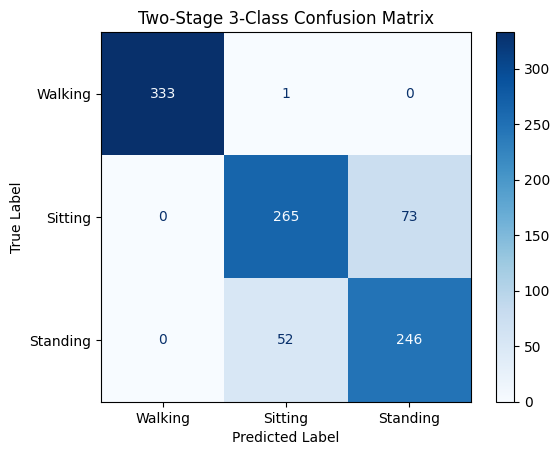

In [ ]:
label_map_3class = {
    "Walking": 0,
    "Sitting": 1,
    "Standing": 2
}

full_df = fusion_df.copy()
full_df["target_3class"] = full_df["activity_name"].map(label_map_3class)

X_full = full_df.drop(columns=["subject_id", "activity_name", "window_seq", "target_3class"])
y_full = full_df["target_3class"]
groups_full = full_df["subject_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups_full))

X_full_train = X_full.iloc[train_idx].reset_index(drop=True)
X_full_test = X_full.iloc[test_idx].reset_index(drop=True)

y_full_train = y_full.iloc[train_idx].reset_index(drop=True)
y_full_test = y_full.iloc[test_idx].reset_index(drop=True)

train_meta = full_df.iloc[train_idx].reset_index(drop=True)
test_meta = full_df.iloc[test_idx].reset_index(drop=True)

# stage1 train/test
y1_train_full = (train_meta["activity_name"] == "Walking").astype(int)
y1_test_full = (test_meta["activity_name"] == "Walking").astype(int)

# stage2 train/test (static만)
static_train_mask = train_meta["activity_name"].isin(["Sitting", "Standing"])
static_test_mask = test_meta["activity_name"].isin(["Sitting", "Standing"])

X2_train_full = X_full_train[static_train_mask].reset_index(drop=True)
y2_train_full = train_meta.loc[static_train_mask, "activity_name"].map({
    "Sitting": 0,
    "Standing": 1
}).reset_index(drop=True)

X2_test_full = X_full_test[static_test_mask].reset_index(drop=True)
y2_test_full = test_meta.loc[static_test_mask, "activity_name"].map({
    "Sitting": 0,
    "Standing": 1
}).reset_index(drop=True)

# 모델 다시 학습
stage1_model_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=42))
])

stage2_model_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=42))
])


stage1_model_full.fit(X_full_train, y1_train_full)
stage2_model_full.fit(X2_train_full, y2_train_full)

# 최종 3분류 예측
y_full_pred = predict_3class_with_two_stage(
    stage1_model_full,
    stage2_model_full,
    X_full_test
)

target_names_3class = ["Walking", "Sitting", "Standing"]

print("=== Final 3-Class Evaluation ===")
print("Accuracy:", accuracy_score(y_full_test, y_full_pred))
print(classification_report(y_full_test, y_full_pred, target_names=target_names_3class))
print("Confusion Matrix:")
print(confusion_matrix(y_full_test, y_full_pred))


cm = confusion_matrix(y_full_test, y_full_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names_3class
)

disp.plot(values_format="d", cmap="Blues")
plt.title("Two-Stage 3-Class Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

=== Final 3-Class Evaluation ===
Accuracy: 0.8701030927835052
              precision    recall  f1-score   support

     Walking       1.00      1.00      1.00       334
     Sitting       0.83      0.78      0.81       338
    Standing       0.77      0.83      0.80       298

    accuracy                           0.87       970
   macro avg       0.87      0.87      0.87       970
weighted avg       0.87      0.87      0.87       970

Confusion Matrix:
[[333   1   0]
 [  0 265  73]
 [  0  52 246]]


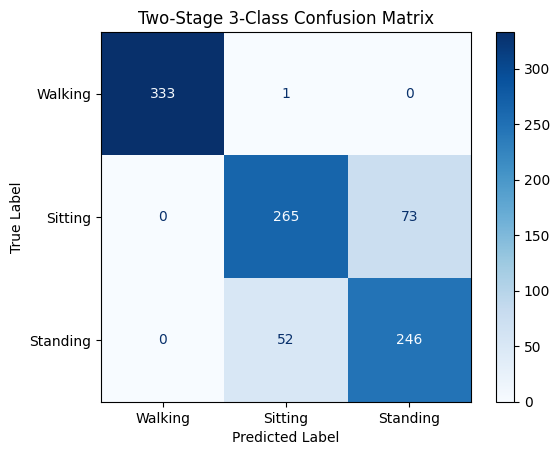


=== Stage1 Permutation Importance (SVM) ===
                   feature  importance
22     accel_magnitude_std    0.025979
28           noise_score_x    0.025979
1              accel_x_std    0.001340
31              gyro_x_min    0.000928
23     accel_magnitude_min    0.000722
53      gyro_magnitude_max    0.000722
54    gyro_magnitude_range    0.000722
52      gyro_magnitude_min    0.000515
2              accel_x_min    0.000000
3              accel_x_max    0.000000
9              accel_y_min    0.000000
8              accel_y_std    0.000000
11           accel_y_range    0.000000
12          accel_y_median    0.000000
16             accel_z_min    0.000000
15             accel_z_std    0.000000
13          accel_y_energy    0.000000
14            accel_z_mean    0.000000
21    accel_magnitude_mean    0.000000
17             accel_z_max    0.000000
18           accel_z_range    0.000000
5           accel_x_median    0.000000
6           accel_x_energy    0.000000
7             accel

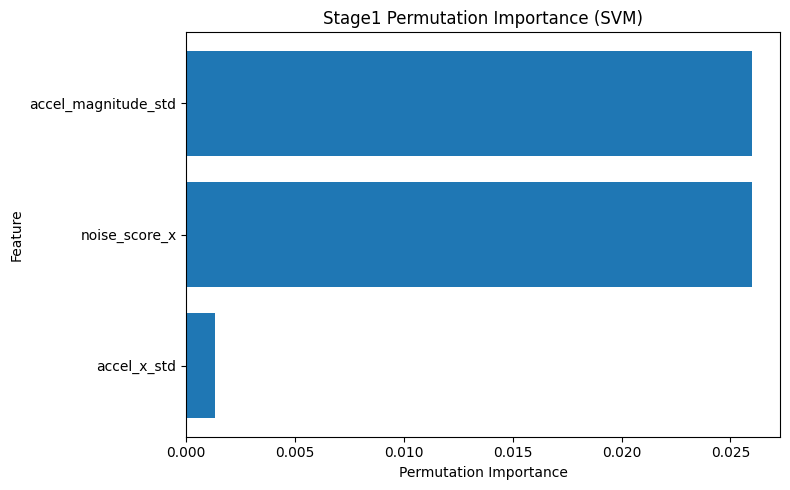


=== Stage2 Permutation Importance (SVM) ===
                   feature  importance
6           accel_x_energy    0.041038
26  accel_magnitude_median    0.006604
21    accel_magnitude_mean    0.005189
37              gyro_y_std    0.004717
27  accel_magnitude_energy    0.004560
5           accel_x_median    0.001730
13          accel_y_energy    0.001415
46              gyro_z_max    0.001101
12          accel_y_median    0.001101
7             accel_y_mean    0.000786
40            gyro_y_range    0.000786
0             accel_x_mean    0.000786
10             accel_y_max    0.000472
4            accel_x_range    0.000314
43             gyro_z_mean    0.000157
48           gyro_z_median    0.000157
22     accel_magnitude_std    0.000157
19          accel_z_median    0.000157
28           noise_score_x    0.000157
8              accel_y_std    0.000000
35           gyro_x_energy    0.000000
42           gyro_y_energy    0.000000
47            gyro_z_range    0.000000
49           gyro_z

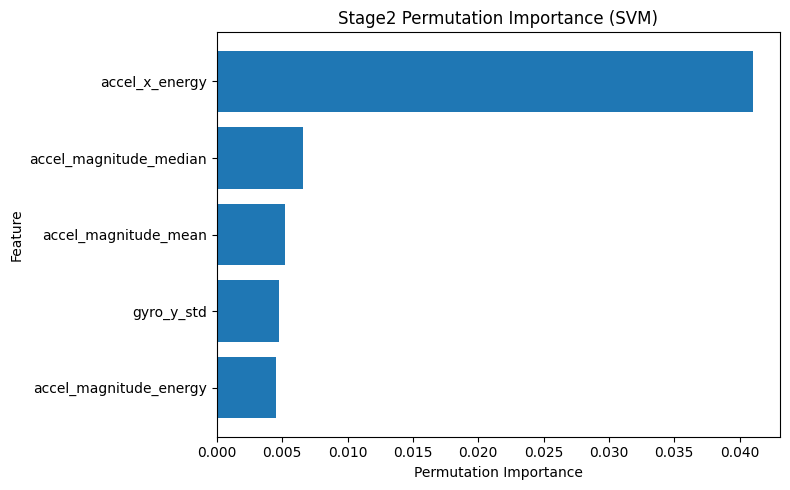

In [222]:

# ------------------------------------------------------------
# Pipeline이면 마지막 estimator 꺼내기
# ------------------------------------------------------------
def get_final_estimator(model):
    if isinstance(model, Pipeline):
        return model.steps[-1][1]
    return model


# ------------------------------------------------------------
# estimator에서 중요도 추출
# ------------------------------------------------------------
def get_feature_importance_df_from_estimator(estimator, feature_names):
    if hasattr(estimator, "feature_importances_"):
        importances = estimator.feature_importances_

    elif hasattr(estimator, "coef_"):
        coef = estimator.coef_
        if coef.ndim == 1:
            importances = np.abs(coef)
        else:
            importances = np.mean(np.abs(coef), axis=0)

    else:
        raise ValueError(f"{type(estimator).__name__} 모델은 특징 중요도를 직접 지원하지 않습니다.")

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)


# ------------------------------------------------------------
# feature name 추출
# ------------------------------------------------------------
def get_feature_names(X):
    if hasattr(X, "columns"):
        return list(X.columns)
    return [f"feature_{i}" for i in range(X.shape[1])]


# ------------------------------------------------------------
# 중요도 시각화
# ------------------------------------------------------------
def plot_feature_importance(model, X_train, title, top_n=10):
    estimator = get_final_estimator(model)
    feature_names = get_feature_names(X_train)

    importance_df = get_feature_importance_df_from_estimator(estimator, feature_names)

    print(f"\n=== {title} ===")
    print(importance_df)

    top_df = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 최종 3분류 예측
# ------------------------------------------------------------
y_full_pred = predict_3class_with_two_stage(
    stage1_model_full,
    stage2_model_full,
    X_full_test
)

target_names_3class = ["Walking", "Sitting", "Standing"]

print("=== Final 3-Class Evaluation ===")
print("Accuracy:", accuracy_score(y_full_test, y_full_pred))
print(classification_report(y_full_test, y_full_pred, target_names=target_names_3class))

# ------------------------------------------------------------
# 혼동행렬
# ------------------------------------------------------------
cm = confusion_matrix(y_full_test, y_full_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names_3class
)

disp.plot(values_format="d", cmap="Blues")
plt.title("Two-Stage 3-Class Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

    
from sklearn.inspection import permutation_importance


def plot_permutation_importance(
    model,
    X_eval,
    y_eval,
    title,
    top_n=10,
    scoring="accuracy",
    n_repeats=10,
    random_state=42
):
    feature_names = get_feature_names(X_eval)

    result = permutation_importance(
        estimator=model,
        X=X_eval,
        y=y_eval,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)

    print(f"\n=== {title} ===")
    print(importance_df)

    top_df = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.title(title)
    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    
    
    
    
plot_permutation_importance(
    model=stage1_model_full,
    X_eval=X_full_test,
    y_eval=y1_test_full,
    title="Stage1 Permutation Importance (SVM)",
    top_n=3,
    scoring="accuracy",
    n_repeats=10,
    random_state=42
)

plot_permutation_importance(
    model=stage2_model_full,
    X_eval=X2_test_full,
    y_eval=y2_test_full,
    title="Stage2 Permutation Importance (SVM)",
    top_n=5,
    scoring="accuracy",
    n_repeats=10,
    random_state=42
)

In [ ]:
'''
# ============================================================
# 1단 분류: Walking / Sitting / Standing 직접 3분류
# ============================================================

label_map_3class = {
    "Walking": 0,
    "Sitting": 1,
    "Standing": 2
}

full_df = fusion_df.copy()
full_df = full_df[full_df["activity_name"].isin(label_map_3class.keys())].copy()
full_df["target_3class"] = full_df["activity_name"].map(label_map_3class)

# 진짜 feature만 선택
# - accel_/gyro_ 로 시작하는 컬럼만 사용
# - noise_score가 남아있으면 제외
feature_cols = [
    c for c in full_df.columns
    if c.startswith(("accel_", "gyro_")) and "noise_score" not in c
]

X_full = full_df[feature_cols].copy()
y_full = full_df["target_3class"]
groups_full = full_df["subject_id"]

print("=== 1단 분류 데이터 확인 ===")
print("X shape:", X_full.shape)
print("y shape:", y_full.shape)
print()
print("[클래스 분포]")
print(full_df["activity_name"].value_counts())
print()
print("[사용 feature 수]")
print(len(feature_cols))
print()
print("[앞부분 데이터]")
display(full_df[["subject_id", "activity_name", "window_seq"] + feature_cols[:6]].head())

def make_group_split_with_idx(X, y, groups, test_size=0.2, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)

    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    group_train = groups.iloc[train_idx].reset_index(drop=True)
    group_test = groups.iloc[test_idx].reset_index(drop=True)

    return X_train, X_test, y_train, y_test, group_train, group_test, train_idx, test_idx

X_full_train, X_full_test, y_full_train, y_full_test, g_full_train, g_full_test, train_idx, test_idx = make_group_split_with_idx(
    X_full, y_full, groups_full,
    test_size=0.2,
    random_state=42
)

train_meta = full_df.iloc[train_idx].reset_index(drop=True)
test_meta = full_df.iloc[test_idx].reset_index(drop=True)

print("=== 1단 분류 split 결과 ===")
print("train shape:", X_full_train.shape)
print("test shape :", X_full_test.shape)
print()
print("[train activity 분포]")
print(train_meta["activity_name"].value_counts())
print()
print("[test activity 분포]")
print(test_meta["activity_name"].value_counts())
print()
print("[train subject]")
print(sorted(train_meta["subject_id"].unique()))
print()
print("[test subject]")
print(sorted(test_meta["subject_id"].unique()))

# ============================================================
# 1단 3분류 모델 학습
# ============================================================

one_stage_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=3.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

one_stage_model.fit(X_full_train, y_full_train)

y_full_pred = one_stage_model.predict(X_full_test)

target_names_3class = ["Walking", "Sitting", "Standing"]

print("=== 1단 직접 3분류 결과 ===")
print("Accuracy:", accuracy_score(y_full_test, y_full_pred))
print(classification_report(y_full_test, y_full_pred, target_names=target_names_3class))
print("Confusion Matrix:")
print(confusion_matrix(y_full_test, y_full_pred))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_full_test,
    y_full_pred,
    display_labels=target_names_3class,
    cmap="Blues",
    xticks_rotation=0
)
plt.title("One-Stage 3-Class Confusion Matrix")
plt.show()
'''

'\n# ============================================================\n# 1단 분류: Walking / Sitting / Standing 직접 3분류\n# ============================================================\n\nlabel_map_3class = {\n    "Walking": 0,\n    "Sitting": 1,\n    "Standing": 2\n}\n\nfull_df = fusion_df.copy()\nfull_df = full_df[full_df["activity_name"].isin(label_map_3class.keys())].copy()\nfull_df["target_3class"] = full_df["activity_name"].map(label_map_3class)\n\n# 진짜 feature만 선택\n# - accel_/gyro_ 로 시작하는 컬럼만 사용\n# - noise_score가 남아있으면 제외\nfeature_cols = [\n    c for c in full_df.columns\n    if c.startswith(("accel_", "gyro_")) and "noise_score" not in c\n]\n\nX_full = full_df[feature_cols].copy()\ny_full = full_df["target_3class"]\ngroups_full = full_df["subject_id"]\n\nprint("=== 1단 분류 데이터 확인 ===")\nprint("X shape:", X_full.shape)\nprint("y shape:", y_full.shape)\nprint()\nprint("[클래스 분포]")\nprint(full_df["activity_name"].value_counts())\nprint()\nprint("[사용 feature 수]")\nprint(len(feature_cols))\npri

In [ ]:
SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(exist_ok=True)

joblib.dump(stage1_model_full, SAVE_DIR / "stage1_walking_vs_static.pkl")
joblib.dump(stage2_model_full, SAVE_DIR / "stage2_sitting_vs_standing.pkl")

print("모델 저장 완료:", SAVE_DIR)

모델 저장 완료: ..\models


In [ ]:

# ============================================================
# 실험 결과 저장
# - 현재 실행된 WINDOW_SIZE / STEP_SIZE / SKIP_HEAD 기준 결과를 CSV에 누적 저장
# - 같은 설정을 다시 저장하면 마지막 결과로 덮어씀
# ============================================================

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = RESULTS_DIR / "window_experiment_results.csv"

EXPERIMENT_NOTE = ""   # 필요하면 메모 수기로 입력 (예: "SVM rbf, baseline")

stage1_acc = accuracy_score(y1_test, y1_pred)
stage2_acc = accuracy_score(y2_test, y2_pred)
final_3class_acc = accuracy_score(y_full_test, y_full_pred)

current_result = pd.DataFrame([{
    "window_size": WINDOW_SIZE,
    "step_size": STEP_SIZE,
    "skip_head": SKIP_HEAD,
    "stage1_acc": stage1_acc,
    "stage2_acc": stage2_acc,
    "final_3class_acc": final_3class_acc,
    "n_stage1_train": len(X1_train),
    "n_stage1_test": len(X1_test),
    "n_stage2_train": len(X2_train),
    "n_stage2_test": len(X2_test),
    "n_full_train": len(X_full_train),
    "n_full_test": len(X_full_test),
    "note": EXPERIMENT_NOTE
}])

if RESULTS_PATH.exists():
    results_df = pd.read_csv(RESULTS_PATH)
    results_df = pd.concat([results_df, current_result], ignore_index=True)
else:
    results_df = current_result.copy()

# 같은 실험 설정(window/step/skip)이 여러 번 저장되면 마지막 결과만 남김
results_df = (
    results_df
    .drop_duplicates(subset=["window_size", "step_size", "skip_head"], keep="last")
    .sort_values(["window_size", "step_size", "skip_head"])
    .reset_index(drop=True)
)

results_df.to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")

print("저장 완료:", RESULTS_PATH)
display(results_df)


저장 완료: ..\results\window_experiment_results.csv


,window_size,step_size,skip_head,stage1_acc,stage2_acc,final_3class_acc,n_stage1_train,n_stage1_test,n_stage2_train,n_stage2_test,n_full_train,n_full_test,note
0,50,25,80,1.0,0.768803,0.880403,16008,4072,10841,2699,16008,4072,NaN
1,100,50,80,1.0,0.747906,0.878331,7888,1989,5312,1313,7888,1989,NaN
2,150,75,80,1.0,0.752056,0.874613,5132,1292,3457,851,5132,1292,NaN
3,200,100,80,1.0,0.745283,0.870103,3852,970,2586,636,3852,970,


,window_size,step_size,skip_head,stage1_acc,stage2_acc,final_3class_acc,n_stage1_train,n_stage1_test,n_stage2_train,n_stage2_test,n_full_train,n_full_test,note
0,50,25,80,1.0,0.768803,0.880403,16008,4072,10841,2699,16008,4072,NaN
1,100,50,80,1.0,0.747906,0.878331,7888,1989,5312,1313,7888,1989,NaN
2,150,75,80,1.0,0.752056,0.874613,5132,1292,3457,851,5132,1292,NaN
3,200,100,80,1.0,0.745283,0.870103,3852,970,2586,636,3852,970,NaN


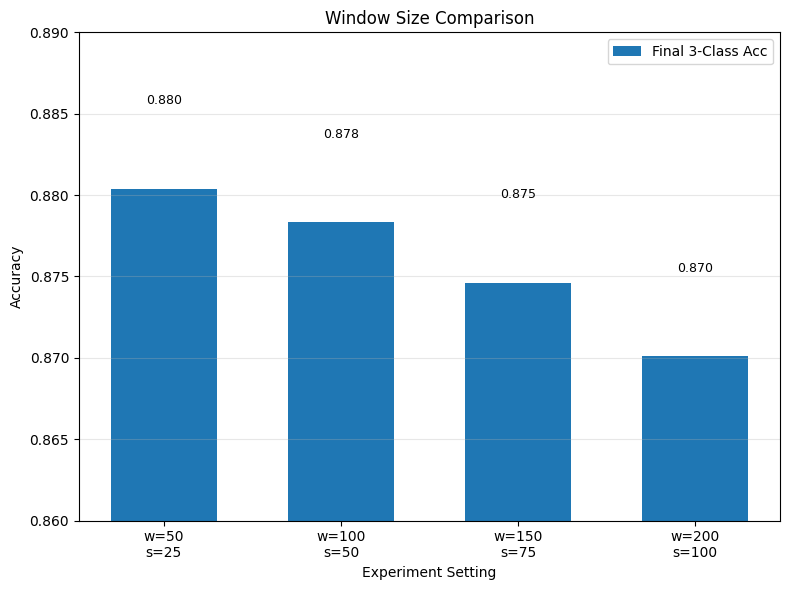

window_size별 최고 성능 요약


,window_size,stage1_acc,stage2_acc,final_3class_acc
0,50,1.0,0.768803,0.880403
1,100,1.0,0.747906,0.878331
2,150,1.0,0.752056,0.874613
3,200,1.0,0.745283,0.870103


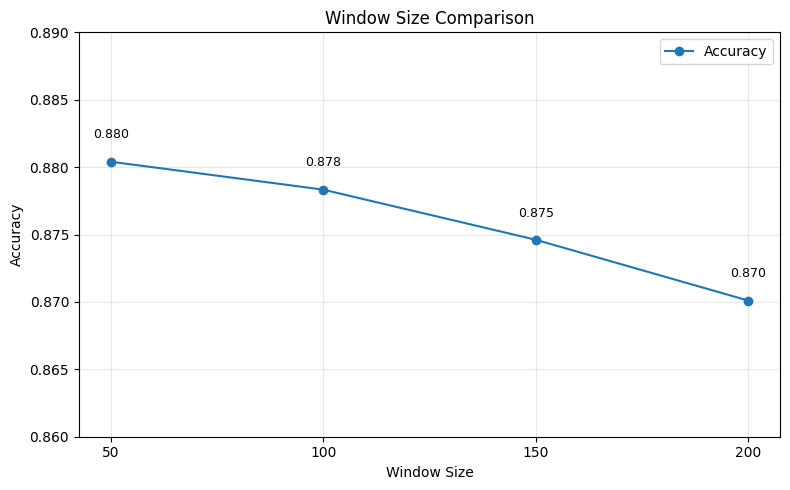

In [ ]:
# ============================================================
# 누적 실험 결과 시각화 - 막대그래프 버전
# - 필요하면 FILTER_STEP_SIZE / FILTER_SKIP_HEAD 값을 고정해서 비교
# - 기본은 저장된 전체 결과를 그대로 그림
# ============================================================

RESULTS_PATH = Path("../results/window_experiment_results.csv")

if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"실험 결과 파일이 없습니다: {RESULTS_PATH}")

results_df = pd.read_csv(RESULTS_PATH)

FILTER_STEP_SIZE = None   # 예: 50
FILTER_SKIP_HEAD = None   # 예: 80

plot_df = results_df.copy()

if FILTER_STEP_SIZE is not None:
    plot_df = plot_df[plot_df["step_size"] == FILTER_STEP_SIZE]

if FILTER_SKIP_HEAD is not None:
    plot_df = plot_df[plot_df["skip_head"] == FILTER_SKIP_HEAD]

plot_df = plot_df.sort_values(["window_size", "step_size", "skip_head"]).reset_index(drop=True)

display(plot_df)

if plot_df.empty:
    print("조건에 맞는 실험 결과가 없습니다.")
else:
    x = np.arange(len(plot_df))
    width = 0.6

    plt.figure(figsize=(8, 6))

    bars = plt.bar(x + width, plot_df["final_3class_acc"], width, label="Final 3-Class Acc")

    xtick_labels = [
        f"w={int(row.window_size)}\ns={int(row.step_size)}"
        for _, row in plot_df.iterrows()
    ]
    plt.xticks(x + width, xtick_labels)

    # 값 표시
    for bars in [bars]:
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.005,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    title = "Window Size Comparison"
    if FILTER_STEP_SIZE is not None or FILTER_SKIP_HEAD is not None:
        title += f" (step={FILTER_STEP_SIZE}, skip={FILTER_SKIP_HEAD})"

    plt.title(title)
    plt.xlabel("Experiment Setting")
    plt.ylabel("Accuracy")
    plt.ylim(0.86, 0.89)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # window_size별 최고 성능 한 번 더 표로 보기
    summary_df = (
        plot_df.groupby("window_size", as_index=False)[["stage1_acc", "stage2_acc", "final_3class_acc"]]
        .max()
        .sort_values("window_size")
        .reset_index(drop=True)
    )

    print("window_size별 최고 성능 요약")
    display(summary_df)
    summary_df = (
    plot_df.groupby("window_size", as_index=False)[["final_3class_acc"]]
    .max()
    .sort_values("window_size")
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 5))

plt.plot(
    summary_df["window_size"],
    summary_df["final_3class_acc"],
    marker="o",
    label="Accuracy"
)

for x, y in zip(summary_df["window_size"], summary_df["final_3class_acc"]):
    plt.text(x, y + 0.0015, f"{y:.3f}", ha="center", va="bottom", fontsize=9)

plt.title("Window Size Comparison")
plt.xlabel("Window Size")
plt.ylabel("Accuracy")
plt.xticks(summary_df["window_size"])
plt.ylim(0.86, 0.89)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
'''
from pathlib import Path
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
}

STAGE2_MODEL_KEY = "GradientBoosting"

stage2_model_full = clone(models[STAGE2_MODEL_KEY])
stage2_model_full.fit(X2_train_full, y2_train_full)

y2_pred_full = stage2_model_full.predict(X2_test_full)
stage2_acc = accuracy_score(y2_test_full, y2_pred_full)
'''

'\nfrom pathlib import Path\nimport pandas as pd\nfrom sklearn.base import clone\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.svm import SVC\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier\n\nmodels = {\n    "LogisticRegression": Pipeline([\n        ("scaler", StandardScaler()),\n        ("model", LogisticRegression(max_iter=2000, random_state=42))\n    ]),\n    "SVM": Pipeline([\n        ("scaler", StandardScaler()),\n        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))\n    ]),\n    "KNN": Pipeline([\n        ("scaler", StandardScaler()),\n        ("model", KNeighborsClassifier(n_neighbors=5))\n    ]),\n    "RandomForest": RandomForestClassifier(\n        n_estimators=200,\n        random_state=42,\n        n_jobs=-1\n    ),\n    "GradientBoosting": GradientBoostingCla

In [ ]:
'''
import json
from sklearn.model_selection import GridSearchCV
tuning_configs = {
    "RandomForest_tuned": {
        "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10, 15],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt", "log2"],
        },
    },
    "GradientBoosting_tuned": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [100, 200],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4],
            "subsample": [0.8, 1.0],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
        },
    },
}

new_rows = []

for model_key, config in tuning_configs.items():
    print(f"\n[{model_key}] 튜닝 시작")

    grid = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["param_grid"],
        scoring="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X2_train_full, y2_train_full)

    best_model = grid.best_estimator_
    y2_pred_full = best_model.predict(X2_test_full)
    stage2_acc = accuracy_score(y2_test_full, y2_pred_full)

    row = {
        "window_size": int(WINDOW_SIZE),
        "step_size": int(STEP_SIZE),
        "skip_head": int(SKIP_HEAD),
        "stage2_model_key": model_key,
        "stage2_model_name": best_model.__class__.__name__,
        
        "stage2_acc": float(stage2_acc),
        "cv_best_score": float(grid.best_score_),
        "stage2_best_params": json.dumps(grid.best_params_, ensure_ascii=False),
    }

    new_rows.append(row)
MODEL_RESULTS_PATH = Path("../reports/results/model_experiment_results.csv")

# 기존 결과 불러오기
if MODEL_RESULTS_PATH.exists():
    model_results_df = pd.read_csv(MODEL_RESULTS_PATH)
else:
    model_results_df = pd.DataFrame()

# 컬럼 자동 보정
required_cols = list(new_rows[0].keys())
for col in required_cols:
    if col not in model_results_df.columns:
        model_results_df[col] = pd.NA

# 같은 조건 + 같은 모델키면 기존 행 삭제 후 새로 저장
for row in new_rows:
    same_mask = (
        (model_results_df["window_size"] == row["window_size"]) &
        (model_results_df["step_size"] == row["step_size"]) &
        (model_results_df["skip_head"] == row["skip_head"]) &
        (model_results_df["stage2_model_key"] == row["stage2_model_key"])
    )
    model_results_df = model_results_df.loc[~same_mask].copy()

# 새 결과 추가
model_results_df = pd.concat(
    [model_results_df, pd.DataFrame(new_rows)],
    ignore_index=True
)

# 정렬
model_results_df = model_results_df.sort_values(
    ["window_size", "step_size", "skip_head", "stage2_acc"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

# 저장
model_results_df.to_csv(MODEL_RESULTS_PATH, index=False, encoding="utf-8-sig")

print(f"\n저장 완료: {MODEL_RESULTS_PATH}")
display(model_results_df.tail(10))
'''

'\nimport json\nfrom sklearn.model_selection import GridSearchCV\ntuning_configs = {\n    "RandomForest_tuned": {\n        "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),\n        "param_grid": {\n            "n_estimators": [100, 200, 300],\n            "max_depth": [None, 5, 10, 15],\n            "min_samples_split": [2, 5],\n            "min_samples_leaf": [1, 2],\n            "max_features": ["sqrt", "log2"],\n        },\n    },\n    "GradientBoosting_tuned": {\n        "estimator": GradientBoostingClassifier(random_state=42),\n        "param_grid": {\n            "n_estimators": [100, 200],\n            "learning_rate": [0.03, 0.05, 0.1],\n            "max_depth": [2, 3, 4],\n            "subsample": [0.8, 1.0],\n            "min_samples_split": [2, 5],\n            "min_samples_leaf": [1, 2],\n        },\n    },\n}\n\nnew_rows = []\n\nfor model_key, config in tuning_configs.items():\n    print(f"\n[{model_key}] 튜닝 시작")\n\n    grid = GridSearchCV(\n        estimat

In [ ]:
'''
def get_model_name(model):
    if hasattr(model, "named_steps"):
        return model.named_steps["model"].__class__.__name__
    return model.__class__.__name__

MODEL_RESULTS_PATH = Path("../reports/results/model_experiment_results.csv")
MODEL_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

row = {
    "window_size": int(WINDOW_SIZE),
    "step_size": int(STEP_SIZE),
    "skip_head": int(SKIP_HEAD),
    "stage2_model_key": STAGE2_MODEL_KEY,
    "stage2_model_name": get_model_name(stage2_model_full),
    "stage2_acc": float(stage2_acc),
}

if MODEL_RESULTS_PATH.exists():
    model_results_df = pd.read_csv(MODEL_RESULTS_PATH)
else:
    model_results_df = pd.DataFrame(columns=row.keys())

same_mask = (
    (model_results_df["window_size"] == row["window_size"]) &
    (model_results_df["step_size"] == row["step_size"]) &
    (model_results_df["skip_head"] == row["skip_head"]) &
    (model_results_df["stage2_model_key"] == row["stage2_model_key"])
) if not model_results_df.empty else pd.Series(dtype=bool)

if not model_results_df.empty:
    model_results_df = model_results_df.loc[~same_mask].copy()

model_results_df = pd.concat(
    [model_results_df, pd.DataFrame([row])],
    ignore_index=True
)

model_results_df = model_results_df.sort_values(
    ["window_size", "step_size", "skip_head", "stage2_acc"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

model_results_df.to_csv(MODEL_RESULTS_PATH, index=False, encoding="utf-8-sig")

print(f"저장 완료: {MODEL_RESULTS_PATH}")
display(model_results_df.tail(10))
'''

'\ndef get_model_name(model):\n    if hasattr(model, "named_steps"):\n        return model.named_steps["model"].__class__.__name__\n    return model.__class__.__name__\n\nMODEL_RESULTS_PATH = Path("../reports/results/model_experiment_results.csv")\nMODEL_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)\n\nrow = {\n    "window_size": int(WINDOW_SIZE),\n    "step_size": int(STEP_SIZE),\n    "skip_head": int(SKIP_HEAD),\n    "stage2_model_key": STAGE2_MODEL_KEY,\n    "stage2_model_name": get_model_name(stage2_model_full),\n    "stage2_acc": float(stage2_acc),\n}\n\nif MODEL_RESULTS_PATH.exists():\n    model_results_df = pd.read_csv(MODEL_RESULTS_PATH)\nelse:\n    model_results_df = pd.DataFrame(columns=row.keys())\n\nsame_mask = (\n    (model_results_df["window_size"] == row["window_size"]) &\n    (model_results_df["step_size"] == row["step_size"]) &\n    (model_results_df["skip_head"] == row["skip_head"]) &\n    (model_results_df["stage2_model_key"] == row["stage2_model_key"])\n) i

In [ ]:
'''
# ============================================================
# Stage2 모델 비교 시각화 - 현재 결과표 구조 반영
# - 고정된 window_size / step_size / skip_head 에서 stage2 모델 성능 비교
# ============================================================
MODEL_RESULTS_PATH_ = Path("../reports/results/model_experiment_results.csv")

if not MODEL_RESULTS_PATH_.exists():
    raise FileNotFoundError(f"모델 비교 결과 파일이 없습니다: {MODEL_RESULTS_PATH_.resolve()}")

results_df = pd.read_csv(MODEL_RESULTS_PATH_)

plot_df = results_df.copy()
plot_df = plot_df[
    (plot_df["window_size"] == 50) &
    (plot_df["step_size"] == 25) &
    (plot_df["skip_head"] == SKIP_HEAD)
].copy()

if plot_df.empty:
    print("조건에 맞는 모델 비교 결과가 없습니다.")
else:
    plot_df = plot_df.sort_values("stage2_acc", ascending=False).reset_index(drop=True)
    plot_df["rank"] = np.arange(1, len(plot_df) + 1)

    display_cols = [
        "rank",
        "stage2_model_key",
        "stage2_model_name",
        "stage2_acc",
        "cv_best_score",
        "stage2_best_params",
    ]
    display(plot_df[display_cols])

    x = np.arange(len(plot_df))
    width = 0.6

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        x,
        plot_df["stage2_acc"],
        width=width,
        label="Stage2 Accuracy"
    )

    plt.xticks(x, plot_df["stage2_model_key"], rotation=20)

    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.001,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    y_min = max(0.0, plot_df["stage2_acc"].min() - 0.02)
    y_max = min(1.0, plot_df["stage2_acc"].max() + 0.02)

    title = f"Stage2 Model Comparison (window={WINDOW_SIZE}, step={STEP_SIZE}, skip={SKIP_HEAD})"

    plt.title(title)
    plt.xlabel("Stage2 Model")
    plt.ylabel("Accuracy")
    plt.ylim(y_min, y_max)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    best_row = plot_df.iloc[0]
    print("Best Stage2 Model")
    print(f"- stage2_model_key  : {best_row['stage2_model_key']}")
    print(f"- stage2_model_name : {best_row['stage2_model_name']}")
    print(f"- stage2_acc        : {best_row['stage2_acc']:.4f}")
    print(f"- cv_best_score     : {best_row['cv_best_score']}")
    print(f"- best_params       : {best_row['stage2_best_params']}")
    '''
    

'\n# ============================================================\n# Stage2 모델 비교 시각화 - 현재 결과표 구조 반영\n# - 고정된 window_size / step_size / skip_head 에서 stage2 모델 성능 비교\n# ============================================================\nMODEL_RESULTS_PATH_ = Path("../reports/results/model_experiment_results.csv")\n\nif not MODEL_RESULTS_PATH_.exists():\n    raise FileNotFoundError(f"모델 비교 결과 파일이 없습니다: {MODEL_RESULTS_PATH_.resolve()}")\n\nresults_df = pd.read_csv(MODEL_RESULTS_PATH_)\n\nplot_df = results_df.copy()\nplot_df = plot_df[\n    (plot_df["window_size"] == 50) &\n    (plot_df["step_size"] == 25) &\n    (plot_df["skip_head"] == SKIP_HEAD)\n].copy()\n\nif plot_df.empty:\n    print("조건에 맞는 모델 비교 결과가 없습니다.")\nelse:\n    plot_df = plot_df.sort_values("stage2_acc", ascending=False).reset_index(drop=True)\n    plot_df["rank"] = np.arange(1, len(plot_df) + 1)\n\n    display_cols = [\n        "rank",\n        "stage2_model_key",\n        "stage2_model_name",\n        "stage2_acc",\n        "cv